# IPL Data Analysis Project

# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading the Dataset

In [2]:
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

# Data Understanding

In this section, the IPL datasets are explored to understand their structure, columns, and overall information.

The analysis includes:
- Viewing sample records
- Checking dataset shape
- Understanding data types
- Identifying missing values

In [3]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
print(matches.shape)
print(deliveries.shape)

(756, 18)
(150460, 21)


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

# Data Cleaning

The datasets were checked for:
- Missing values
- Duplicate records
- Inconsistent information

Some columns contain missing values due to abandoned matches or unavailable match information. These missing values do not significantly affect the analysis.

In [8]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [9]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [10]:
matches.duplicated().sum()

np.int64(0)

In [11]:
deliveries.duplicated().sum()

np.int64(1)

# Most Successful IPL Teams

This visualization shows the total number of matches won by each IPL team.

Mumbai Indians and Chennai Super Kings are the most successful teams in IPL history.

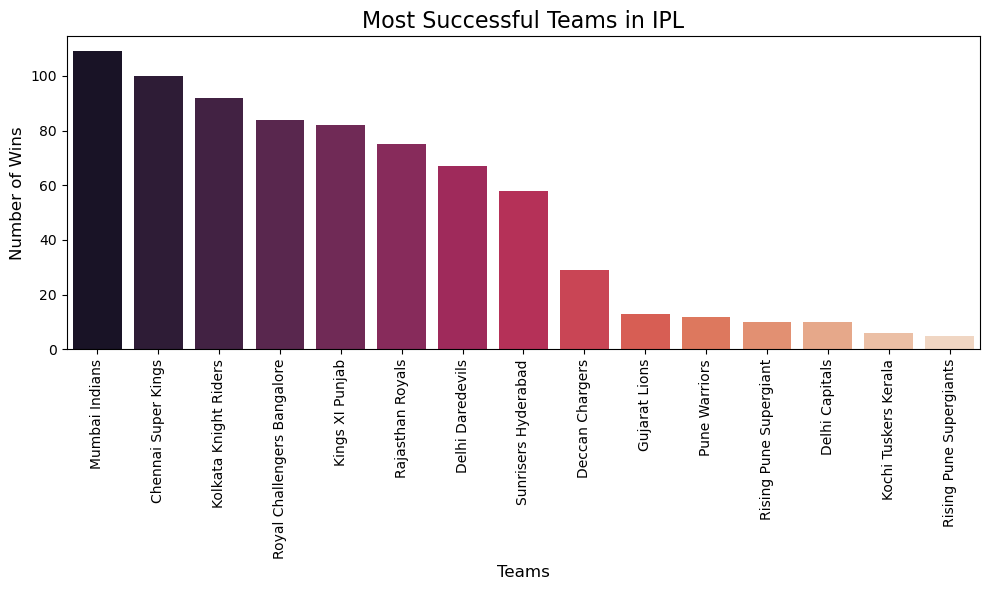

In [12]:
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=team_wins.index, 
    y=team_wins.values,
    hue=team_wins.index, 
    palette='rocket',
    legend=False)

plt.title('Most Successful Teams in IPL', fontsize=16)

plt.xlabel('Teams', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("output/team_wins.png")

# Toss Impact Analysis

In [13]:
toss_match_win = matches[matches['toss_winner'] == matches['winner']]

percentage = (len(toss_match_win) / len(matches)) * 100

print(f"Teams winning toss also won match: {percentage:.2f}%")

Teams winning toss also won match: 51.98%


# Top Run Scorers in IPL

This visualization shows the players who have scored the highest runs in IPL history.

Suresh Raina, Virat Kohli, and Rohit Sharma are among the leading run scorers.

In [14]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

In [15]:
top_batsmen

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64

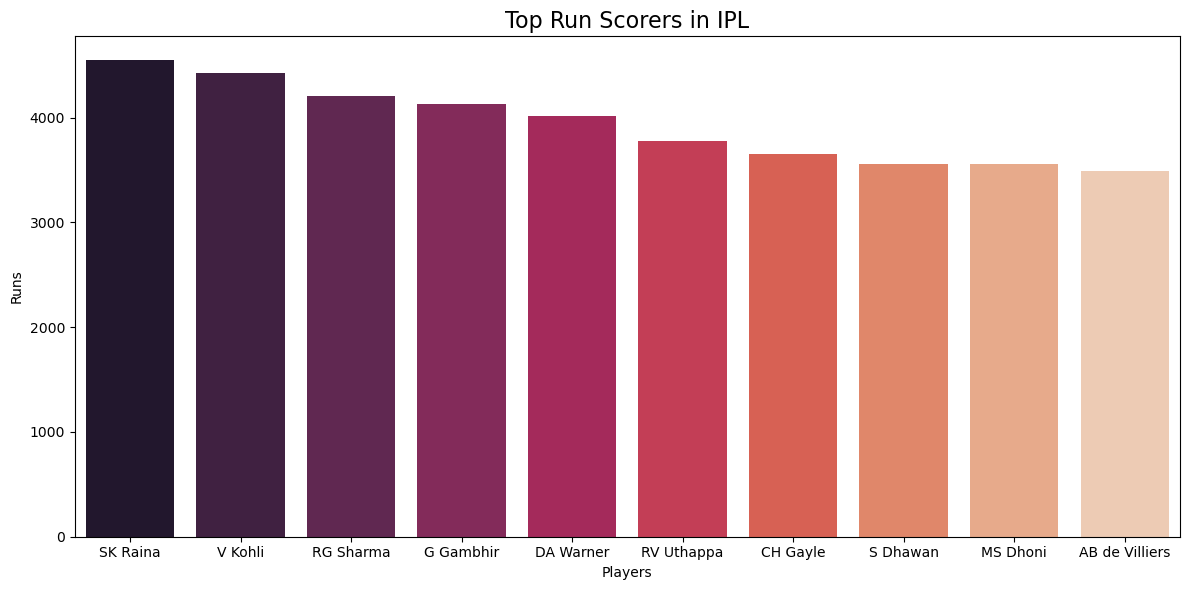

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_batsmen.index,
    y=top_batsmen.values,
    hue=top_batsmen.index,
    palette='rocket',
    legend=False
)

plt.title("Top Run Scorers in IPL", fontsize=16)

plt.xlabel("Players")
plt.ylabel("Runs")


plt.tight_layout()

plt.savefig("output/top_batsmen.png")


# Top Wicket Takers in IPL

This analysis highlights the bowlers with the highest number of wickets in IPL history.

Lasith Malinga emerges as the leading wicket-taker in the dataset.

In [17]:
wickets = deliveries[deliveries['player_dismissed'].notnull()]

top_bowlers = wickets['bowler'].value_counts().head(10)

In [18]:
top_bowlers

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: count, dtype: int64

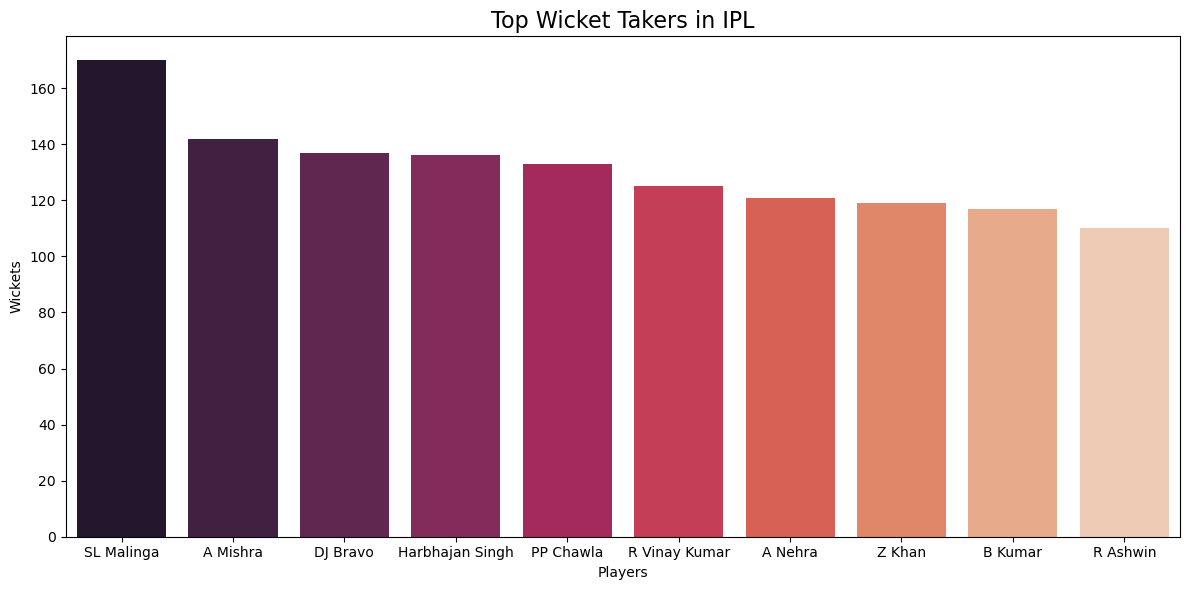

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_bowlers.index,
    y=top_bowlers.values,
    hue=top_bowlers.index,
    palette='rocket',
    legend=False
)

plt.title("Top Wicket Takers in IPL", fontsize=16)

plt.xlabel("Players")
plt.ylabel("Wickets")

plt.tight_layout()

plt.savefig("output/top_bowlers.png")

# Players With Most Sixes in IPL

This analysis highlights the most destructive power hitters in IPL history.

Chris Gayle leads the chart with the highest number of sixes.

In [20]:
sixes = deliveries[deliveries['batsman_runs'] == 6]

top_six_hitters = sixes['batsman'].value_counts().head(10)

In [21]:
top_six_hitters

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
V Kohli           160
DA Warner         160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
Name: count, dtype: int64

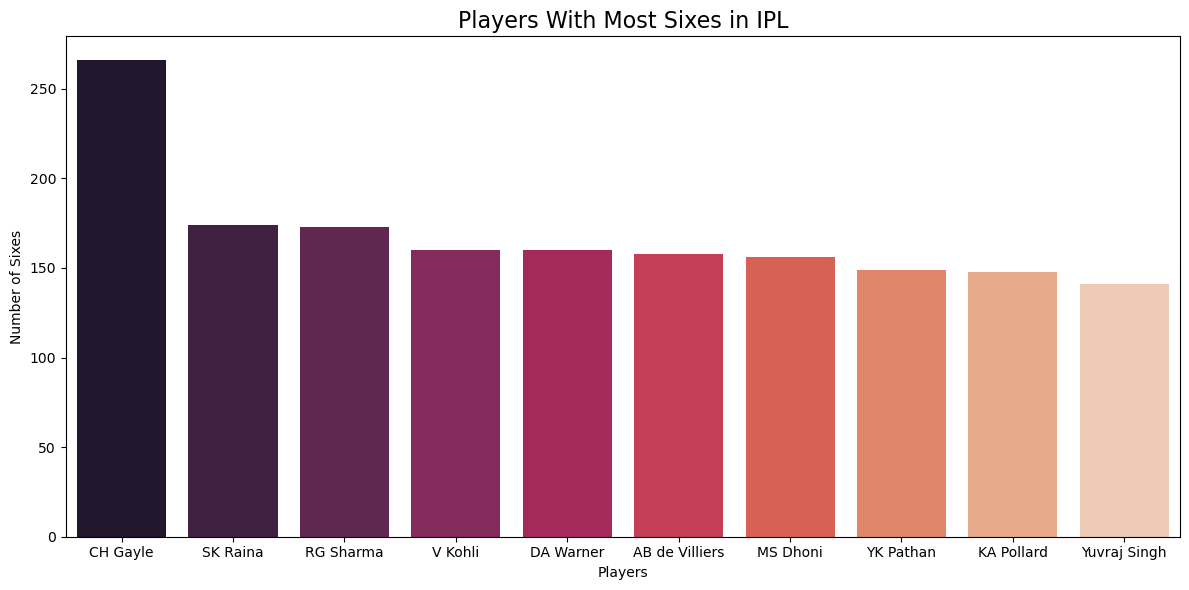

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_six_hitters.index,
    y=top_six_hitters.values,
    hue=top_six_hitters.index,
    palette='rocket',
    legend=False
)

plt.title("Players With Most Sixes in IPL", fontsize=16)

plt.xlabel("Players")
plt.ylabel("Number of Sixes")

plt.tight_layout()

plt.savefig("output/top_six_hitters.png")

# Top IPL Venues

This analysis highlights the stadiums that have hosted the highest number of IPL matches.

Eden Gardens, M Chinnaswamy Stadium, and Wankhede Stadium are among the most frequently used venues.

In [23]:
top_venues = matches['venue'].value_counts().head(10)

In [24]:
top_venues

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Subrata Roy Sahara Stadium                    17
Name: count, dtype: int64

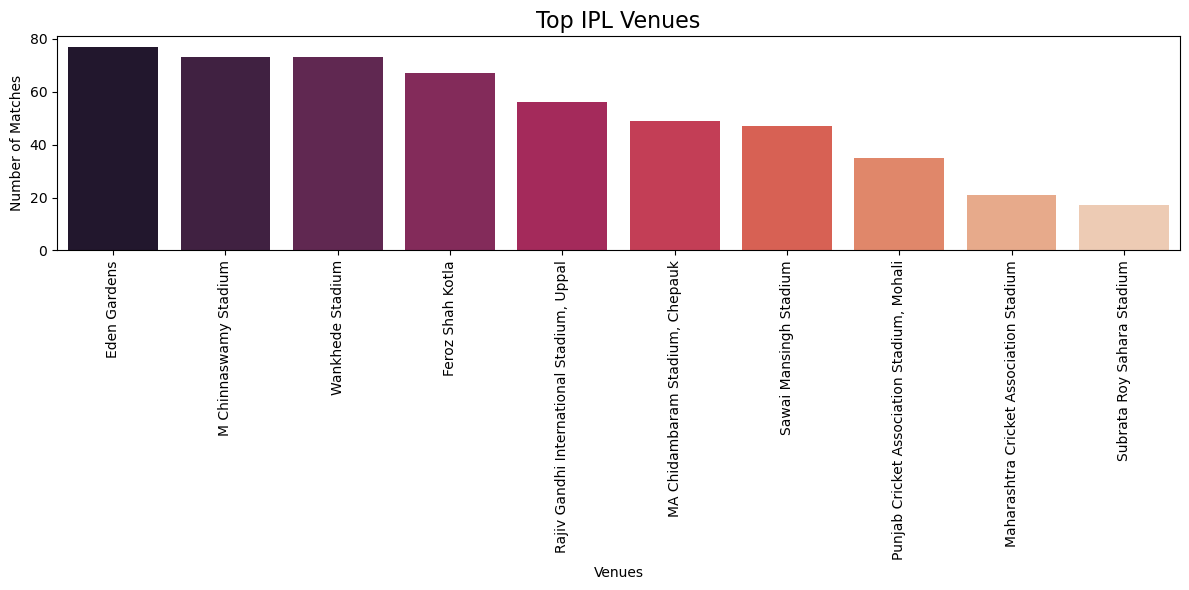

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_venues.index,
    y=top_venues.values,
    hue=top_venues.index,
    palette='rocket',
    legend=False
)

plt.title("Top IPL Venues", fontsize=16)
plt.xlabel("Venues")
plt.ylabel("Number of Matches")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("output/top_venues.png")

# Season-wise IPL Matches

This visualization shows how the number of IPL matches changed over different seasons.

The IPL expanded significantly during 2011–2013 before stabilizing in later years.

In [26]:
season_matches = matches['season'].value_counts().sort_index()

In [27]:
season_matches

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

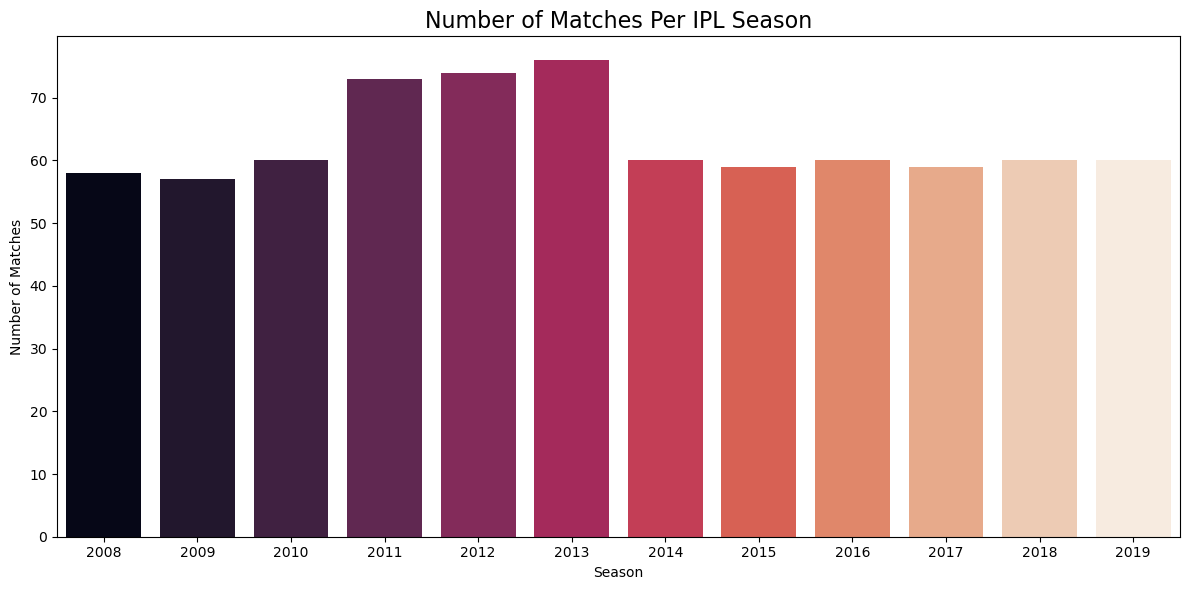

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=season_matches.index,
    y=season_matches.values,
    hue=season_matches.index,
    palette='rocket',
    legend=False
)

plt.title("Number of Matches Per IPL Season", fontsize=16)

plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.tight_layout()

plt.savefig("output/season_matches.png")

# Conclusion

This project explored IPL data using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.

Key insights from the analysis include:

- Mumbai Indians and Chennai Super Kings are among the most successful teams.
- Winning the toss provides a noticeable advantage.
- Suresh Raina and Virat Kohli are among the leading run scorers.
- Lasith Malinga is one of the highest wicket takers.
- Chris Gayle dominates six-hitting statistics.
- Eden Gardens has hosted the highest number of IPL matches.

This project demonstrates the use of data cleaning, exploratory data analysis, grouping, aggregation, and data visualization techniques on real-world sports data.

In [29]:
print("IPL Data Analysis Project Completed Successfully!")

IPL Data Analysis Project Completed Successfully!
